# Aynsley Kretschmar (sak2300) Final Project
# Trends in Land Use Change in Countries with High Land Use Pressures - Brazil, Indonesia, The Democratic Republic of the Congo, and Russia

## Scientific Question(s):
How does land use change vary by country between 1992 and today among Brazil, Indonesia, the DRC, and Russia? Which of these countries are experiencing the biggest losses in forest land and in forest carbon stock, and what types of land is forest land in these four nations being converted into? 

## Hypotheses:
1) Forests are the land use category experiencing the most change, driven by the transition of forest land into agricultural land and built land (categorized into other).
2) Forest carbon stocks are declining in all four nations.
3) The percentage of forest that is planted versus naturally regenerating is increasing over time.


## Why did I choose to explore Brazil, Indonesia, DRC, and Russia?

Brazil: History of deforestation, particularly in the Amazon, caused by soy agriculture and cattle ranching, among other factors.

Indonesia: History of deforestation due to palm oil agriculture.

DRC: History of deforestation due to agriculture and the use of wood for fuel.

Russia: History of tree cover loss due to fires + and industrial expansion.

## FAO Land Statistics Dataset

This dataset provides global land use data at the country-level. Data includes area dedicated to agricultural land, forest land, and other land uses. The data also breaks down type of agricultural land, changes in the forest carbon stock, and the change in naturally regenerating vs planted forests.

### Note: Accessing this dataset requires an API token which much be updated every 1 hour. Upon signing up for an account at the website link below, an API token will be generated. The API token can then be pasted into section 2 of the code.

[Link to API Developer Portal - sign up for account and retrieve API token](https://signin.fao.org/login?client_id=2csltsigao85ivhp6ojp1aic7o&redirect_uri=https%3A%2F%2Fwww.fao.org%2Ffaostat%2Fen%2F&response_type=code&scope=aws.cognito.signin.user.admin+email+openid+phone+profile&state=b5c81a461a884d9b9abf6a1e34f8acaf&code_challenge=ZNcGMk4TJ444j1hzdPft_Q_XCYV0nrQrqBEfn3eRDLY&code_challenge_method=S256)



If of interest, more information about the dataset can be found here:

[Link to online data download](https://www.fao.org/faostat/en/#data/RL)

[Link to most recent Analytical Brief](https://openknowledge.fao.org/server/api/core/bitstreams/6a9f71f4-885f-453a-813b-0397c772d37d/content)

## Analysis Approach

1) Importing Python libraries
2) Pulling in FAO data
3) Dataset exploration and creating separate data tables for each country; as part of exploration, also determining what data types duplicate measurements (e.g. arable land is a category of agriculture and both should not be used in an additive way at the same time)
4) Analyzing land use by area - Charting land use over time; Calculating and plotting year-over-year percent change; Studied for 1992-2023 to allow for a consistent time range across countries.
6) Analyzing agricultural land share - Plotting percentage of agricultural land in each category over time; Studied for 1992-2023 to allow for a consistent time range across countries.
7) Analyzing carbon stocks - Creating comparative chart of 1992 vs 2025 using subset of data; Calculating and plotting year-over-year percent change; Studied for 1992-2025 to allow for a consistent time range across countries.
8) Analyzing naturally regenerative vs planted forest - Plotting forest type over time; Plotting comparative percent planted forest over time by country; Studied for 1992-2025 to allow for a consistent time range across countries.


### 1) Import Python Libraries

In [5]:
# import requests and pandas in order to be able to pull in data from FAO API and format into pandas dataframe
import requests
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np

### 2) Pull in data from FAO for Brazil, Indonesia, the DRC, and Russia
Note: API token must be updated every hour

In [6]:
# save FAO API access token
token = "eyJraWQiOiJVSFE2dmwrekFTaGRpSGpsOFFSK0d2ZW13RWIzSjZNdytYNTRURXZtNUNJPSIsImFsZyI6IlJTMjU2In0.eyJzdWIiOiJkZTMyMTVhYy04MWFiLTQ4ZDItOWEzMi1lZDIyNDJjOTE2N2MiLCJpc3MiOiJodHRwczpcL1wvY29nbml0by1pZHAuZXUtd2VzdC0xLmFtYXpvbmF3cy5jb21cL2V1LXdlc3QtMV9iTkVMTk9DMnYiLCJ2ZXJzaW9uIjoyLCJjbGllbnRfaWQiOiIyY3NsdHNpZ2FvODVpdmhwNm9qcDFhaWM3byIsIm9yaWdpbl9qdGkiOiIzNzk0MzFlNi1lNjFhLTQ0ZTctYTAyNy03Yjg1YjNiZDg0MjEiLCJldmVudF9pZCI6IjNiYjhhOGZlLTA3NDEtNDQ1MC05NTMxLTQ4M2Y5YzA5ZDA3OCIsInRva2VuX3VzZSI6ImFjY2VzcyIsInNjb3BlIjoiYXdzLmNvZ25pdG8uc2lnbmluLnVzZXIuYWRtaW4gcGhvbmUgb3BlbmlkIHByb2ZpbGUgZW1haWwiLCJhdXRoX3RpbWUiOjE3Nzg2MDMwNTgsImV4cCI6MTc3ODYyMTE2OCwiaWF0IjoxNzc4NjE3NTY4LCJqdGkiOiI2ZGEwYThlZC1lZDhmLTQwZDItYWNmOC05NDY0YjUxZWQ0MDEiLCJ1c2VybmFtZSI6InNhazIzMDAifQ.HkoY6C882ZGnDJ4Gi4raAv-BXKBvdT68q1O2s2i4kVXIUo6TS3AWT9A49iJ5B-McDw5Lf8wZ5PB7X-1frH6fmj3uJD5cZHHo9hUeJA3SHYKbIdjoO4u4aBbx5XooMvu2dKeBlkWIt5p-_84BHrKIOGLOaPu43rU0Z5gppFSLbP0RzXP4pV40Qpiy2xQt3yGEI4NLdAc83wyiCB6vMhmkSLyQ87ns0s53tf3l9bD1OR1BPN4CYrisaX-6ikCmu7JW3IIpQIsosp0715BgM3inCaXtnsL5voi8tjkgWXhqmkNYDDTkT5qyGXVmpOBI_Q0SJHWiPenfZaChZWG6Nhvf6g"

In [7]:
# pull data from FAO API
url = "https://faostatservices.fao.org/api/v1/en/data/RL"

# set parameters - numbers signify country code
params = {
    "area": "21,101,250,185"      
}

# provide authorization token
headers = {
    "Authorization": f"Bearer {token}"
}

# store pulled data
response = requests.get(
    url,
    headers=headers,
    params=params
)

# ensure data was accessed successfully - 200 means data pull was successful; 403 means unsuccessful -> check if token needs to be updated!
print(response.status_code)

200


In [8]:
# save data as data table
data = response.json()

# convert to pandas data frame for ease of use
df = pd.json_normalize(data["data"])

# explore data - look at heading titles
df.head()

,Domain Code,Domain,Area Code,Area,Element Code,Element,Item Code,Item,Year Code,Year,Unit,Value,Flag,Flag Description,Note
0,RL,Land Use,21,Brazil,5110,Area,6600,Country area,1961,1961,1000 ha,851577,A,Official figure,
1,RL,Land Use,21,Brazil,5110,Area,6600,Country area,1962,1962,1000 ha,851577,A,Official figure,
2,RL,Land Use,21,Brazil,5110,Area,6600,Country area,1963,1963,1000 ha,851577,A,Official figure,
3,RL,Land Use,21,Brazil,5110,Area,6600,Country area,1964,1964,1000 ha,851577,A,Official figure,
4,RL,Land Use,21,Brazil,5110,Area,6600,Country area,1965,1965,1000 ha,851577,A,Official figure,


### 3) Examine Dataset and Separate Data by Country

In [9]:
# determine unique Elements of dataset
df['Element'].unique()

array(['Area', 'Share in Land area',
       'Value of agricultural production (Int. $) per Area',
       'Share in Agricultural land', 'Area per capita',
       'Carbon stock in living biomass', 'Share in Forest land',
       'Share in Cropland'], dtype=object)

In [10]:
# What are units for each element?
units = df.groupby('Element')['Unit'].unique()
print(units)

Element
Area                                                     [1000 ha]
Area per capita                                           [ha/cap]
Carbon stock in living biomass                         [million t]
Share in Agricultural land                                     [%]
Share in Cropland                                              [%]
Share in Forest land                                           [%]
Share in Land area                                             [%]
Value of agricultural production (Int. $) per Area    [USD_PPP/ha]
Name: Unit, dtype: object


In [11]:
# sort data by year for plotting
df = df.sort_values(by='Year')
type(df.Year)

# set year and value columns to numbers
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')
df['Value'] = pd.to_numeric(df['Value'], errors='coerce')

In [12]:
# separate data into separate dataframes by country
df_BR = df[df.Area == 'Brazil']
df_ID = df[df.Area == 'Indonesia']
df_DRC = df[df.Area == 'Democratic Republic of the Congo']
df_RU = df[df.Area == 'Russian Federation']

### 4) Land Use by Area (thousands of hectares) 
This dataset has a lot of overlapping measurements and potential for double counting. Therefore, here I am separating Area data into separate data frames. I am pivoting the data in order to be able to create stacked area charts. I am also selecting only area measurements that are not duplicative (e.g. agricultural land has several measurement "Items" within the "Area" element. I am calculating percent change year-over-year, and then I am separating out the percent change calculated data and the raw data to avoid any issues with plotting. The percent change is calculated using the pct_change Pandas function which takes (new value - prior value)/prior value. I am then multiplying by 100 to convert the resulting decimal into a percentage.

In [13]:
# separate Area data into separate data tables

# Brazil
# pull in only Area data
Area_BR = df_BR[df_BR.Element == 'Area']
# print Items to help w filtering
print(Area_BR['Item'].unique())
# pivot to enable plotting
Area_BR = Area_BR.pivot_table(index='Year', columns='Item', values='Value', aggfunc='sum').reset_index()
print(Area_BR)

# Indonesia
# pull in only Area data
Area_ID = df_ID[df_ID.Element == 'Area']
# print Items to help w filtering
print(Area_ID['Item'].unique())
# pivot to enable plotting
Area_ID = Area_ID.pivot_table(index='Year', columns='Item', values='Value', aggfunc='sum').reset_index()
print(Area_ID)


# DRC
# pull in only Area data
Area_DRC = df_DRC[df_DRC.Element == 'Area']
# print Items to help w filtering
print(Area_DRC['Item'].unique())
# pivot to enable plotting
Area_DRC = Area_DRC.pivot_table(index='Year', columns='Item', values='Value', aggfunc='sum').reset_index()
print(Area_DRC)


# Russia
# pull in only Area data
Area_RU = df_RU[df_RU.Element == 'Area']
# print Items to help w filtering
print(Area_RU['Item'].unique())
# pivot to enable plotting
Area_RU = Area_RU.pivot_table(index='Year', columns='Item', values='Value', aggfunc='sum').reset_index()
print(Area_RU)

['Country area' 'Agricultural land' 'Agriculture' 'Cropland'
 'Permanent meadows and pastures' 'Arable land' 'Inland waters'
 'Land area equipped for irrigation' 'Land area' 'Permanent crops'
 'Planted Forest' 'Other land' 'Primary Forest' 'Forest land'
 'Naturally regenerating forest' 'Temporary crops'
 'Temporary meadows and pastures' 'Temporary fallow'
 'Perm. meadows & pastures - Nat. growing'
 'Perm. meadows & pastures - Cultivated'
 'Agriculture area under organic agric.'
 'Agriculture area actually irrigated'
 'Agriculture area certified organic' 'Land used for aquaculture'
 'Inland waters used for aquac. or holding facilities'
 'Inland waters used for capture fisheries'
 'Coastal waters used for aquac. or holding facilities'
 'Coastal waters used for capture fisheries'
 'EEZ used for aquac. or holding facilities'
 'EEZ used for capture fisheries']
Item  Year  Agricultural land  Agriculture  \
0     1961           156959.0     156959.0   
1     1962           160666.0     160666

In [14]:
# filter Area df to only specific Items to avoid duplication of land area

# Brazil
# choose columns to keep to avoid duplication
Area_select_BR = Area_BR[['Year','Agricultural land', 'Forest land', 'Other land']]
# setting time range because big jump in amount of data tracked in 1990 and not all data after 2023 is in
Area_select_BR = Area_select_BR[(Area_select_BR['Year'] >= 1992)  & (Area_select_BR['Year'] <= 2023)]
print(Area_select_BR)

# Indonesia
# filter Area df to only specific Items to avoid duplication of land area
Area_select_ID = Area_ID[['Year','Agricultural land', 'Forest land', 'Other land']]
# setting time range because big jump in amount of data tracked in 1990 and not all data after 2023 is in
Area_select_ID = Area_select_ID[(Area_select_ID['Year'] >= 1992)  & (Area_select_ID['Year'] <= 2023)]
print(Area_select_ID)

# DRC
# filter Area df to only specific Items to avoid duplication of land area
Area_select_DRC = Area_DRC[['Year','Agricultural land', 'Forest land', 'Other land']]
# setting time range because big jump in amount of data tracked in 1990 and not all data after 2023 is in
Area_select_DRC = Area_select_DRC[(Area_select_DRC['Year'] >= 1992)  & (Area_select_DRC['Year'] <= 2023)]
print(Area_select_DRC)

# Russia
# filter Area df to only specific Items to avoid duplication of land area
Area_select_RU = Area_RU[['Year','Agricultural land', 'Forest land', 'Other land']]
# setting time range because big jump in amount of data tracked in 1990 and not all data after 2023 is in
Area_select_RU = Area_select_RU[(Area_select_RU['Year'] >= 1992)  & (Area_select_RU['Year'] <= 2023)]
print(Area_select_RU)

Item  Year  Agricultural land  Forest land  Other land
31    1992           232060.4   606898.682       0.000
32    1993           230640.6   601126.393    4047.007
33    1994           229220.8   595354.104   11239.096
34    1995           227805.0   589581.815   18427.185
35    1996           227908.7   583809.526   24095.774
36    1997           228012.4   578037.237   29764.363
37    1998           228116.1   572264.948   35432.952
38    1999           228219.8   566492.659   41101.541
39    2000           228323.5   560720.370   46770.130
40    2001           228427.2   557157.077   50229.723
41    2002           228530.9   553593.784   53689.316
42    2003           228634.6   550030.491   57148.909
43    2004           228738.3   546467.198   60608.502
44    2005           228842.0   542903.905   64068.095
45    2006           228951.0   539340.612   67522.388
46    2007           229671.8   535777.319   70364.881
47    2008           230392.6   532214.026   73207.374
48    2009

In [15]:
# calculate percent change - area
# calculation is (value) * ((value - prior value)/value) * 100

# Brazil
# calculating percent change for each column
Area_select_BR['Agricultural Land % Change'] = Area_select_BR['Agricultural land'].pct_change()*100
Area_select_BR['Forest Land % Change'] = Area_select_BR['Forest land'].pct_change()*100
Area_select_BR['Other Land % Change'] = Area_select_BR['Other land'].pct_change()*100
print(Area_select_BR)

# Indonesia
# calculating percent change for each column
Area_select_ID['Agricultural Land % Change'] = Area_select_ID['Agricultural land'].pct_change()*100
Area_select_ID['Forest Land % Change'] = Area_select_ID['Forest land'].pct_change()*100
Area_select_ID['Other Land % Change'] = Area_select_ID['Other land'].pct_change()*100
print(Area_select_ID)

# DRC
# calculating percent change for each column
Area_select_DRC['Agricultural Land % Change'] = Area_select_DRC['Agricultural land'].pct_change()*100
Area_select_DRC['Forest Land % Change'] = Area_select_DRC['Forest land'].pct_change()*100
Area_select_DRC['Other Land % Change'] = Area_select_DRC['Other land'].pct_change()*100
print(Area_select_BR)

# Russia
# calculating percent change for each column
Area_select_RU['Agricultural Land % Change'] = Area_select_RU['Agricultural land'].pct_change()*100
Area_select_RU['Forest Land % Change'] = Area_select_RU['Forest land'].pct_change()*100
Area_select_RU['Other Land % Change'] = Area_select_RU['Other land'].pct_change()*100
print(Area_select_RU)

Item  Year  Agricultural land  Forest land  Other land  \
31    1992           232060.4   606898.682       0.000   
32    1993           230640.6   601126.393    4047.007   
33    1994           229220.8   595354.104   11239.096   
34    1995           227805.0   589581.815   18427.185   
35    1996           227908.7   583809.526   24095.774   
36    1997           228012.4   578037.237   29764.363   
37    1998           228116.1   572264.948   35432.952   
38    1999           228219.8   566492.659   41101.541   
39    2000           228323.5   560720.370   46770.130   
40    2001           228427.2   557157.077   50229.723   
41    2002           228530.9   553593.784   53689.316   
42    2003           228634.6   550030.491   57148.909   
43    2004           228738.3   546467.198   60608.502   
44    2005           228842.0   542903.905   64068.095   
45    2006           228951.0   539340.612   67522.388   
46    2007           229671.8   535777.319   70364.881   
47    2008    

In [16]:
# make table that does not have percentages (to not interfere with stacked area plot)

# selecting only columns that are not the calculated percentages
Area_select_BR_gross = Area_select_BR[['Year','Agricultural land', 'Forest land', 'Other land']]
Area_select_ID_gross = Area_select_ID[['Year','Agricultural land', 'Forest land', 'Other land']]
Area_select_DRC_gross = Area_select_DRC[['Year','Agricultural land', 'Forest land', 'Other land']]
Area_select_RU_gross = Area_select_RU[['Year','Agricultural land', 'Forest land', 'Other land']]

# checking to confirm this worked properly
print(Area_select_BR_gross)
print(Area_select_ID_gross)
print(Area_select_DRC_gross)
print(Area_select_RU_gross)

Item  Year  Agricultural land  Forest land  Other land
31    1992           232060.4   606898.682       0.000
32    1993           230640.6   601126.393    4047.007
33    1994           229220.8   595354.104   11239.096
34    1995           227805.0   589581.815   18427.185
35    1996           227908.7   583809.526   24095.774
36    1997           228012.4   578037.237   29764.363
37    1998           228116.1   572264.948   35432.952
38    1999           228219.8   566492.659   41101.541
39    2000           228323.5   560720.370   46770.130
40    2001           228427.2   557157.077   50229.723
41    2002           228530.9   553593.784   53689.316
42    2003           228634.6   550030.491   57148.909
43    2004           228738.3   546467.198   60608.502
44    2005           228842.0   542903.905   64068.095
45    2006           228951.0   539340.612   67522.388
46    2007           229671.8   535777.319   70364.881
47    2008           230392.6   532214.026   73207.374
48    2009

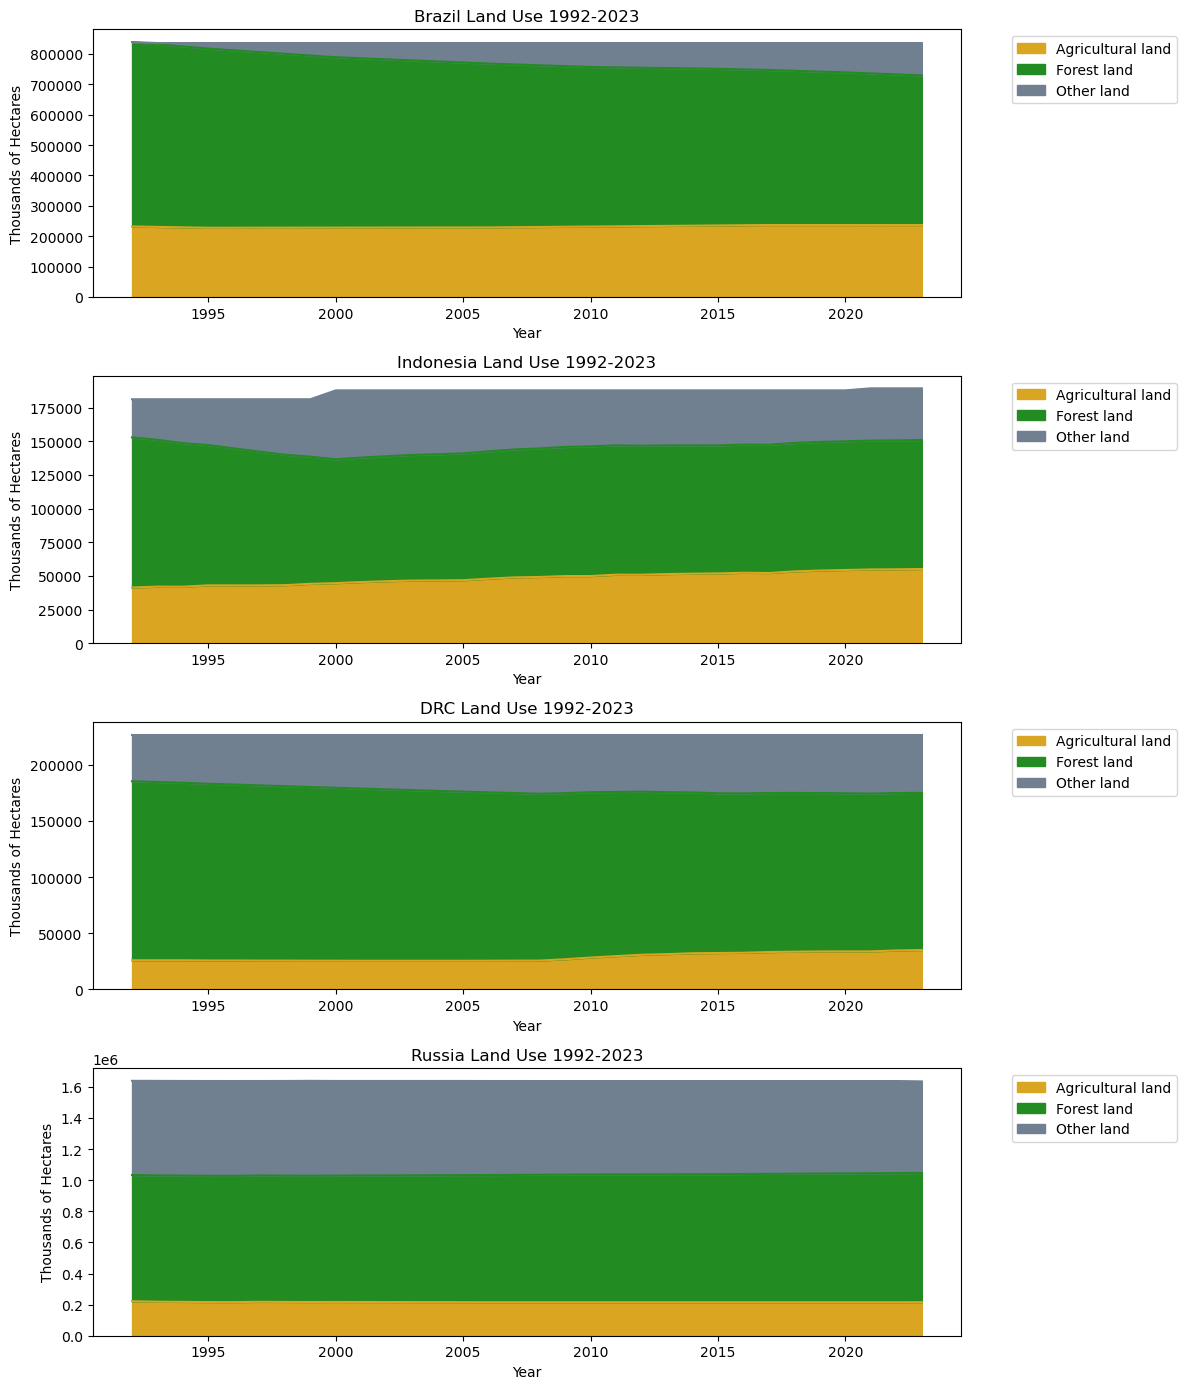

In [17]:
# Plot area change for agricultural land, forest land, and other land

# set up 4 subplot figure
fig,axes = plt.subplots(figsize=(12,14), nrows=4)
ax0,ax1,ax2,ax3 = axes

# set color scheme
area_colors = ['goldenrod', 'forestgreen', 'slategrey']

# Brazil subplot
Area_select_BR_gross.plot(kind='area', x= "Year", stacked=True, ax=ax0, color = area_colors)
# title, axes, legend
ax0.set_title('Brazil Land Use 1992-2023')
ax0.set_ylabel('Thousands of Hectares')
ax0.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Indonesia subplot
Area_select_ID_gross.plot(kind='area', x= "Year", stacked=True, ax=ax1, color = area_colors)
# title, axes, legend
ax1.set_title('Indonesia Land Use 1992-2023')
ax1.set_ylabel('Thousands of Hectares')
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# DRC subplot
Area_select_DRC_gross.plot(kind='area', x= "Year", stacked=True, ax=ax2, color = area_colors)
# title, axes, legend
ax2.set_title('DRC Land Use 1992-2023')
ax2.set_ylabel('Thousands of Hectares')
ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Russia subplot
Area_select_RU_gross.plot(kind='area', x= "Year", stacked=True, ax=ax3, color = area_colors)
# title, axes, legend
ax3.set_title('Russia Land Use 1992-2023')
ax3.set_ylabel('Thousands of Hectares')
ax3.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# fix overlap of axis titles
plt.tight_layout()




### 5) Percent Change in Land Use Type
Here I am plotting the percent change data by land use type by country, calculated in the previous section. The intention is to be able to understand how land use is transitioning from one type to another

In [18]:
# make tables with only the percent change data calculated above

# selecting only percent change columns
Area_select_BR_pctchange = Area_select_BR[['Year','Agricultural Land % Change', 'Forest Land % Change', 'Other Land % Change']]
Area_select_ID_pctchange = Area_select_ID[['Year','Agricultural Land % Change', 'Forest Land % Change', 'Other Land % Change']]
Area_select_DRC_pctchange = Area_select_DRC[['Year','Agricultural Land % Change', 'Forest Land % Change', 'Other Land % Change']]
Area_select_RU_pctchange = Area_select_RU[['Year','Agricultural Land % Change', 'Forest Land % Change', 'Other Land % Change']]

# checking to confirm this worked properly
print(Area_select_BR_pctchange)
print(Area_select_ID_pctchange)
print(Area_select_DRC_pctchange)
print(Area_select_RU_pctchange)

Item  Year  Agricultural Land % Change  Forest Land % Change  \
31    1992                         NaN                   NaN   
32    1993                   -0.611823             -0.951112   
33    1994                   -0.615590             -0.960245   
34    1995                   -0.617658             -0.969556   
35    1996                    0.045521             -0.979048   
36    1997                    0.045501             -0.988728   
37    1998                    0.045480             -0.998602   
38    1999                    0.045459             -1.008674   
39    2000                    0.045439             -1.018952   
40    2001                    0.045418             -0.635485   
41    2002                    0.045397             -0.639549   
42    2003                    0.045377             -0.643666   
43    2004                    0.045356             -0.647836   
44    2005                    0.045336             -0.652060   
45    2006                    0.047631  

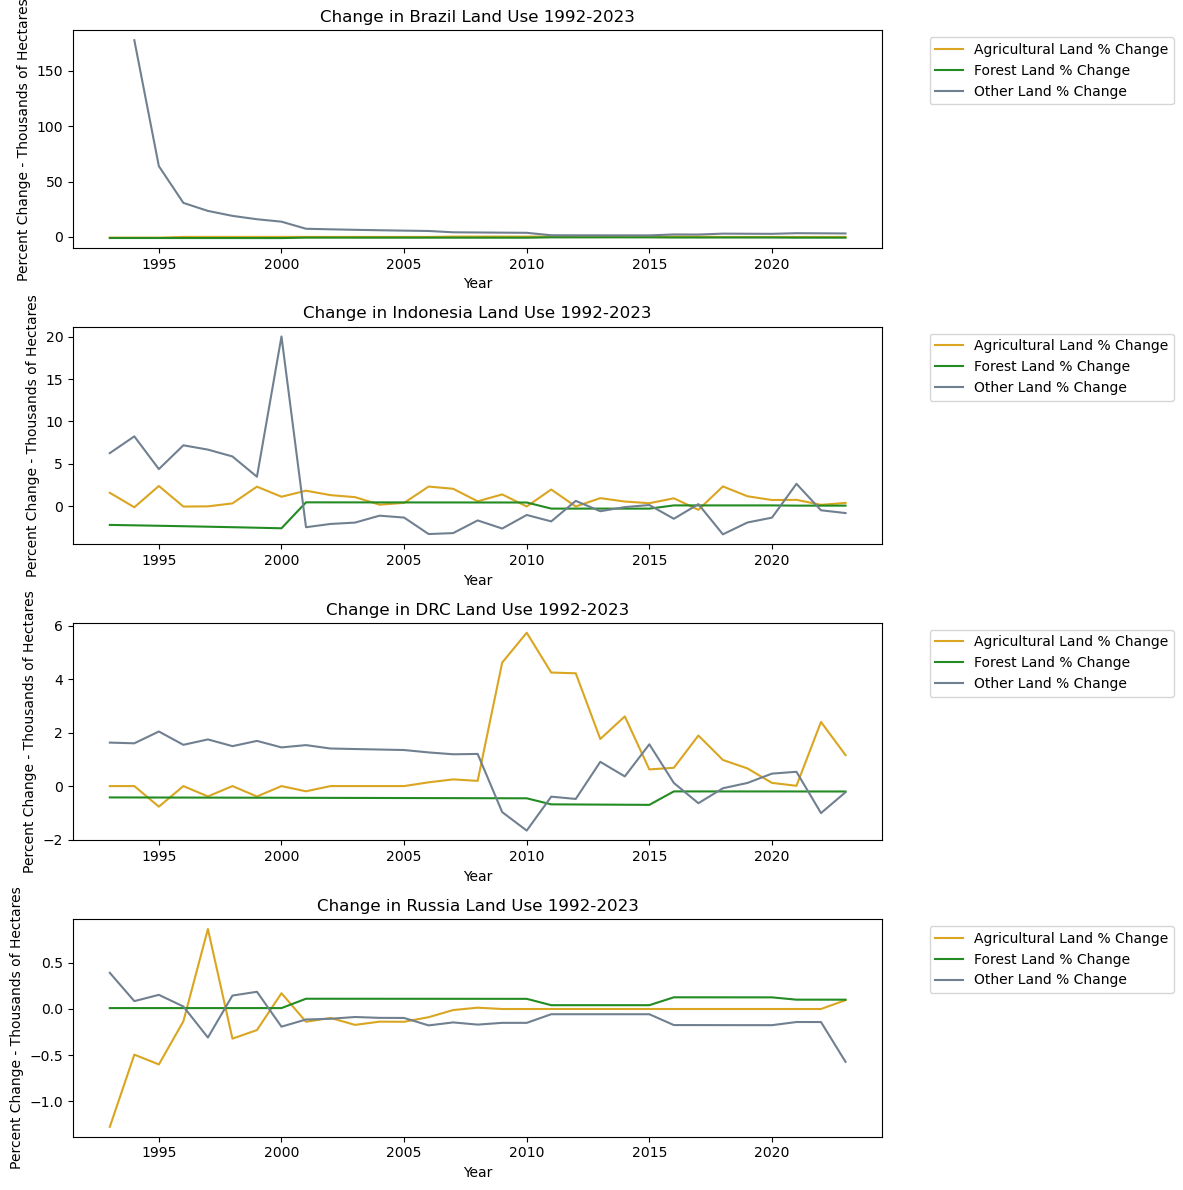

In [19]:
# Plot percent change y-o-y by country

# set up figure with  subplots
fig,axes = plt.subplots(figsize=(12,12), nrows=4)
ax0,ax1,ax2,ax3 = axes

# set color scheme
area_colors = ['goldenrod', 'forestgreen', 'slategrey']

# Brazil subplot
Area_select_BR_pctchange.plot(kind='line', x= "Year", ax=ax0, color = area_colors)
# title, axes, legend
ax0.set_title('Change in Brazil Land Use 1992-2023')
ax0.set_ylabel('Percent Change - Thousands of Hectares')
ax0.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Indonesia subplot
Area_select_ID_pctchange.plot(kind='line', x= "Year", ax=ax1, color = area_colors)
# title, axes, legend
ax1.set_title('Change in Indonesia Land Use 1992-2023')
ax1.set_ylabel('Percent Change - Thousands of Hectares')
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# DRC subplot
Area_select_DRC_pctchange.plot(kind='line', x= "Year", ax=ax2, color = area_colors)
# title, axes, legend
ax2.set_title('Change in DRC Land Use 1992-2023')
ax2.set_ylabel('Percent Change - Thousands of Hectares')
ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Russia subplot
Area_select_RU_pctchange.plot(kind='line', x= "Year", ax=ax3, color = area_colors)
# title, axes, legend
ax3.set_title('Change in Russia Land Use 1992-2023')
ax3.set_ylabel('Percent Change - Thousands of Hectares')
ax3.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# fix overlapping axis titles
plt.tight_layout()


#### 5.1) Zoom in on Land Use Change in Brazil 2000 and On
Here I am duplicating the Brazil graph and filtering to only 2000 and after. This is because there were large increases in other forest land in Brazil in the 90's, to the extent that it made it difficult to interpret the changes that occurred after that point given the size of the y-axis.

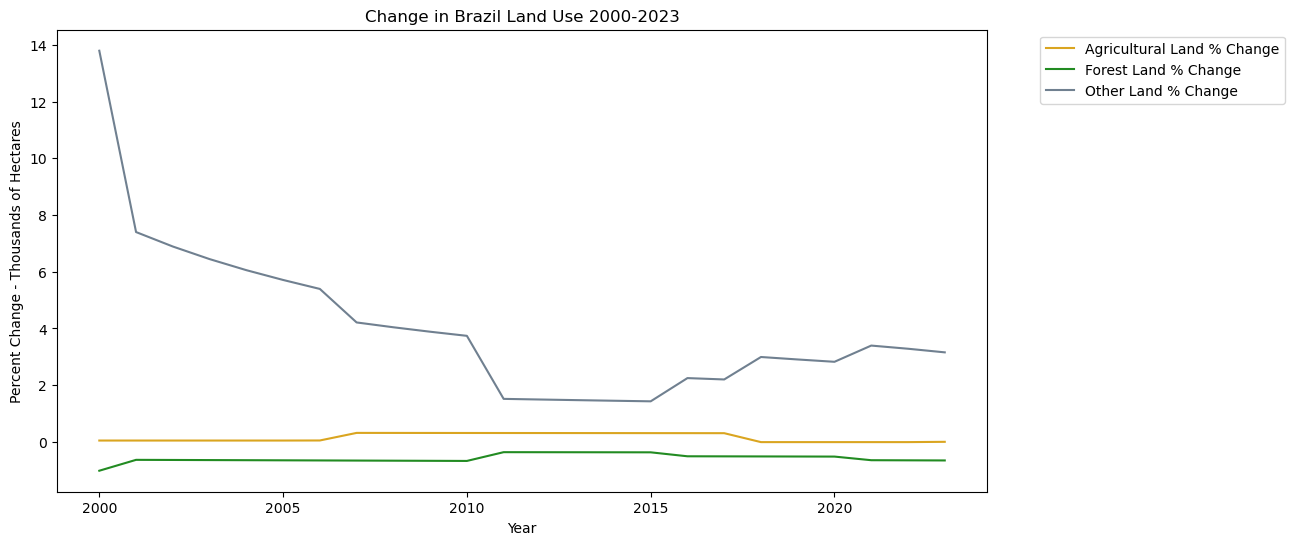

In [20]:
# Zooming in on Brazil after big change - starting in 1996

# filtering for only 2000-2023
Area_select_BR_pctchange_1996 = Area_select_BR_pctchange[(Area_select_BR_pctchange['Year'] >= 2000)  & (Area_select_BR_pctchange['Year'] <= 2023)]


# set up figure
fig,ax = plt.subplots(figsize=(12,6))


# set color scheme
area_colors = ['goldenrod', 'forestgreen', 'slategrey']

# Brazil plot
Area_select_BR_pctchange_1996.plot(kind='line', x= "Year", ax=ax, color = area_colors)
# title, axes, legend
ax.set_title('Change in Brazil Land Use 2000-2023')
ax.set_ylabel('Percent Change - Thousands of Hectares')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

### 6) Agricultural Land Percent Share by Production Type
Here agricultural land share is separated out from other variables into separate data frames. This data is filtered to between 1992-2023, and again Items that are duplicative are excluded through a filtering step. The data is then plotted as a stacked area chart

In [21]:
# filter agriculture share data into separate data frames, pivot data for ease of plotting, filter to shared timeframe, and filter out duplicative measurements. 

# Brazil
# filter to only share of ag land data
Share_AgLand_BR = df_BR[df_BR.Element == 'Share in Agricultural land']
# pivot data for ease of plotting
Share_AgLand_BR = Share_AgLand_BR.pivot_table(index='Year', columns='Item', values='Value', aggfunc='sum').reset_index()
# select only desired data columns
Share_AgLand_select_BR = Share_AgLand_BR[['Year','Arable land', 'Permanent crops', 'Permanent meadows and pastures']]

# select timeframe to align with Russia data availability
Share_AgLand_select_BR = Share_AgLand_select_BR[(Share_AgLand_select_BR['Year'] >= 1992)  & (Share_AgLand_select_BR['Year'] <= 2023)]
print(Share_AgLand_select_BR)


# Indonesia
# filter to only share of ag land data
Share_AgLand_ID = df_ID[df_ID.Element == 'Share in Agricultural land']
# pivot data for ease of plotting
Share_AgLand_ID = Share_AgLand_ID.pivot_table(index='Year', columns='Item', values='Value', aggfunc='sum').reset_index()
# select only desired data columns
Share_AgLand_select_ID = Share_AgLand_ID[['Year','Arable land', 'Permanent crops', 'Permanent meadows and pastures']]

# select timeframe to align with Russia data availability
Share_AgLand_select_ID = Share_AgLand_select_ID[(Share_AgLand_select_ID['Year'] >= 1992)  & (Share_AgLand_select_ID['Year'] <= 2023)]
print(Share_AgLand_select_ID)


# DRC
# filter to only share of ag land data
Share_AgLand_DRC = df_DRC[df_DRC.Element == 'Share in Agricultural land']
# pivot data for ease of plotting
Share_AgLand_DRC = Share_AgLand_DRC.pivot_table(index='Year', columns='Item', values='Value', aggfunc='sum').reset_index()
# select only desired data columns
Share_AgLand_select_DRC = Share_AgLand_DRC[['Year','Arable land', 'Permanent crops', 'Permanent meadows and pastures']]

# select timeframe to align with Russia data availability
Share_AgLand_select_DRC = Share_AgLand_select_DRC[(Share_AgLand_select_DRC['Year'] >= 1992)  & (Share_AgLand_select_DRC['Year'] <= 2023)]
print(Share_AgLand_select_DRC)


# Russia
# filter to only share of ag land data
Share_AgLand_RU = df_RU[df_RU.Element == 'Share in Agricultural land']
# pivot data for ease of plotting
Share_AgLand_RU = Share_AgLand_RU.pivot_table(index='Year', columns='Item', values='Value', aggfunc='sum').reset_index()
# select only desired data columns
Share_AgLand_select_RU = Share_AgLand_RU[['Year','Arable land', 'Permanent crops', 'Permanent meadows and pastures']]

# select timeframe to align with Russia data availability
Share_AgLand_select_RU = Share_AgLand_select_RU[(Share_AgLand_select_RU['Year'] >= 1992)  & (Share_AgLand_select_RU['Year'] <= 2023)]
print(Share_AgLand_select_RU)

Item  Year  Arable land  Permanent crops  Permanent meadows and pastures
31    1992        19.44             3.79                           76.77
32    1993        19.08             3.75                           77.18
33    1994        18.71             3.70                           77.59
34    1995        18.68             3.31                           78.01
35    1996        18.93             3.47                           77.60
36    1997        19.17             3.64                           77.19
37    1998        19.42             3.80                           76.78
38    1999        19.66             3.96                           76.37
39    2000        19.91             4.13                           75.97
40    2001        20.15             4.29                           75.56
41    2002        20.39             4.45                           75.16
42    2003        20.64             4.61                           74.75
43    2004        20.88             4.78           

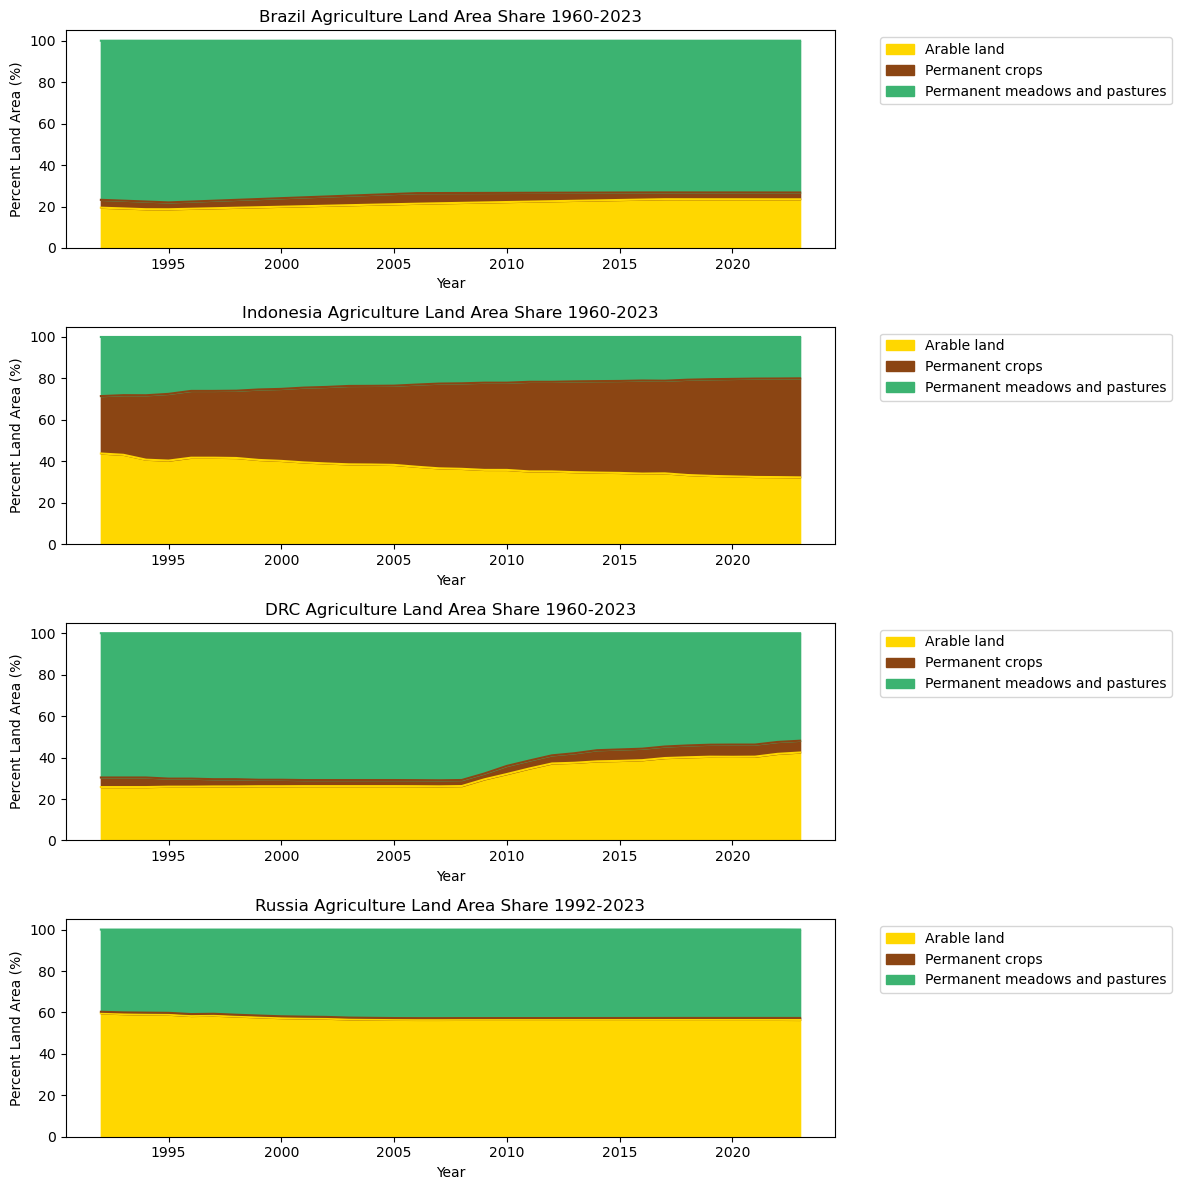

In [22]:
# plot ag area share as stacked area chart by country
# set up figure with 4 subplots
fig,axes = plt.subplots(figsize=(12,12), nrows=4)
ax0,ax1,ax2,ax3 = axes

# set colors
agshare_colors = ['gold', 'saddlebrown', 'mediumseagreen']

# Brazil subplot
Share_AgLand_select_BR.plot(kind='area', x= "Year", stacked=True, ax=ax0, color= agshare_colors)
# title, axes, legend
ax0.set_title('Brazil Agriculture Land Area Share 1960-2023')
ax0.set_ylabel('Percent Land Area (%)')
ax0.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Indonesia subplot
Share_AgLand_select_ID.plot(kind='area', x= "Year", stacked=True, ax=ax1, color= agshare_colors)
# title, axes, legend
ax1.set_title('Indonesia Agriculture Land Area Share 1960-2023')
ax1.set_ylabel('Percent Land Area (%)')
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# DRC subplot
Share_AgLand_select_DRC.plot(kind='area', x= "Year", stacked=True, ax=ax2, color= agshare_colors)
# title, axes, legend
ax2.set_title('DRC Agriculture Land Area Share 1960-2023')
ax2.set_ylabel('Percent Land Area (%)')
ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Russia subplot
Share_AgLand_select_RU.plot(kind='area', x= "Year", stacked=True, ax=ax3, color= agshare_colors)
# title, axes, legend
ax3.set_title('Russia Agriculture Land Area Share 1992-2023')
ax3.set_ylabel('Percent Land Area (%)')
ax3.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# fix issue with axis titles overlapping
plt.tight_layout()



### 7) Carbon Stocks
Here carbon stock data is separated out from other variables into separate data frames. This data is pivoted for ease of plotting, filtered to between 1992-2023. I am calculating percent change year-over-year, and then I am separating out the percent change calculated data and the raw data to avoid any issues with plotting. The percent change is calculated using the pct_change Pandas function which takes (new value - prior value)/prior value. I am then multiplying by 100 to convert the resulting decimal into a percentage.

In [23]:
# separate out carbon stock data into separate dataframes, pivot data for ease of plotting, and filter for a consistent time period across countries

# Brazil
# select only carbon stock data
Carbon_stock_BR = df_BR[df_BR.Element == 'Carbon stock in living biomass']
# pivot data for ease of plotting
Carbon_stock_BR = Carbon_stock_BR.pivot_table(index='Year', columns='Item', values='Value', aggfunc='sum').reset_index()

# select timeframe to align with Russia data availability (starts in 1992)
Carbon_stock_BR = Carbon_stock_BR[(Carbon_stock_BR['Year'] >= 1992)  & (Carbon_stock_BR['Year'] <= 2025)]
print(Carbon_stock_BR)


# Indonesia
# separate out carbon stock data
Carbon_stock_ID = df_ID[df_ID.Element == 'Carbon stock in living biomass']
# pivot data for ease of plotting
Carbon_stock_ID = Carbon_stock_ID.pivot_table(index='Year', columns='Item', values='Value', aggfunc='sum').reset_index()

# select timeframe to align with Russia data availability
Carbon_stock_ID = Carbon_stock_ID[(Carbon_stock_ID['Year'] >= 1992)  & (Carbon_stock_ID['Year'] <= 2025)]
print(Carbon_stock_ID)


# DRC
# separate out carbon stock data
Carbon_stock_DRC = df_DRC[df_DRC.Element == 'Carbon stock in living biomass']
# pivot data for ease of plotting
Carbon_stock_DRC = Carbon_stock_DRC.pivot_table(index='Year', columns='Item', values='Value', aggfunc='sum').reset_index()

# select timeframe to align with Russia data availability
Carbon_stock_DRC = Carbon_stock_DRC[(Carbon_stock_DRC['Year'] >= 1992)  & (Carbon_stock_DRC['Year'] <= 2025)]
print(Carbon_stock_DRC)


# Russia
# separate out carbon stock data
Carbon_stock_RU = df_RU[df_RU.Element == 'Carbon stock in living biomass']
# pivot data for ease of plotting
Carbon_stock_RU = Carbon_stock_RU.pivot_table(index='Year', columns='Item', values='Value', aggfunc='sum').reset_index()

# select timeframe to align with Russia data availability
Carbon_stock_RU = Carbon_stock_RU[(Carbon_stock_RU['Year'] >= 1992)  & (Carbon_stock_RU['Year'] <= 2025)]
print(Carbon_stock_RU)

Item  Year  Forest land
2     1992    59549.686
3     1993    59138.964
4     1994    58728.242
5     1995    58317.520
6     1996    57906.798
7     1997    57496.076
8     1998    57085.354
9     1999    56674.632
10    2000    56263.910
11    2001    55993.987
12    2002    55724.064
13    2003    55454.141
14    2004    55184.218
15    2005    54914.295
16    2006    54644.372
17    2007    54374.449
18    2008    54104.526
19    2009    53834.603
20    2010    53564.680
21    2011    53487.890
22    2012    53411.100
23    2013    53334.310
24    2014    53257.520
25    2015    53180.730
26    2016    52999.076
27    2017    52817.422
28    2018    52635.768
29    2019    52454.114
30    2020    52272.460
31    2021    52025.422
32    2022    51778.384
33    2023    51531.346
34    2024    51284.308
35    2025    51037.270
Item  Year  Forest land
2     1992    12661.778
3     1993    12384.867
4     1994    12107.956
5     1995    11831.045
6     1996    11554.134
7     1997    11

In [24]:
# calculate percent change - carbon stock
# calculation is (value) * ((value - prior value)/value) * 100

# Brazil
Carbon_stock_BR['Forest Carbon Stock % Change'] = Carbon_stock_BR['Forest land'].pct_change()*100

print(Carbon_stock_BR)

# Indonesia
Carbon_stock_ID['Forest Carbon Stock % Change'] = Carbon_stock_ID['Forest land'].pct_change()*100
print(Carbon_stock_ID)

# DRC
Carbon_stock_DRC['Forest Carbon Stock % Change'] = Carbon_stock_DRC['Forest land'].pct_change()*100
print(Carbon_stock_DRC)

# Russia
Carbon_stock_RU['Forest Carbon Stock % Change'] = Carbon_stock_RU['Forest land'].pct_change()*100
print(Carbon_stock_RU)

Item  Year  Forest land  Forest Carbon Stock % Change
2     1992    59549.686                           NaN
3     1993    59138.964                     -0.689713
4     1994    58728.242                     -0.694503
5     1995    58317.520                     -0.699360
6     1996    57906.798                     -0.704286
7     1997    57496.076                     -0.709281
8     1998    57085.354                     -0.714348
9     1999    56674.632                     -0.719488
10    2000    56263.910                     -0.724702
11    2001    55993.987                     -0.479744
12    2002    55724.064                     -0.482057
13    2003    55454.141                     -0.484392
14    2004    55184.218                     -0.486750
15    2005    54914.295                     -0.489131
16    2006    54644.372                     -0.491535
17    2007    54374.449                     -0.493963
18    2008    54104.526                     -0.496415
19    2009    53834.603     

In [25]:
# make table that does not have percentages (to not interfere with stacked area plot)

# selecting only non-percentage data
Carbon_stock_BR_gross = Carbon_stock_BR[['Year', 'Forest land']]
Carbon_stock_ID_gross = Carbon_stock_ID[['Year', 'Forest land']]
Carbon_stock_DRC_gross = Carbon_stock_DRC[['Year', 'Forest land']]
Carbon_stock_RU_gross = Carbon_stock_RU[['Year', 'Forest land']]


# make tables with only percent change data

# selecting only percentage change data
Carbon_stock_BR_pctchange = Carbon_stock_BR[['Year', 'Forest Carbon Stock % Change']]
Carbon_stock_ID_pctchange = Carbon_stock_ID[['Year', 'Forest Carbon Stock % Change']]
Carbon_stock_DRC_pctchange = Carbon_stock_DRC[['Year', 'Forest Carbon Stock % Change']]
Carbon_stock_RU_pctchange = Carbon_stock_RU[['Year', 'Forest Carbon Stock % Change']]



### 7.1) Comparative Carbon Stocks - 1992 versus 2025
Here I am concatenating the four raw data carbon stock data frames, selecting only 1992 and 2025, and then plotting 1992 and 2025 side-by-side for each country, enabling an easy comparison for carbon stock change over time.

In [26]:
# add country column to dfs to enable identification of data after concatenation

Carbon_stock_BR_gross['Country']= 'Brazil'
Carbon_stock_ID_gross['Country'] = 'Indonesia'
Carbon_stock_DRC_gross['Country'] = 'DRC'
Carbon_stock_RU_gross['Country'] = 'Russia'

print(Carbon_stock_RU_gross)



Item  Year  Forest land Country
0     1992    35104.728  Russia
1     1993    35392.217  Russia
2     1994    35679.706  Russia
3     1995    35967.195  Russia
4     1996    36254.684  Russia
5     1997    36542.173  Russia
6     1998    36829.662  Russia
7     1999    37117.151  Russia
8     2000    37404.640  Russia
9     2001    37722.963  Russia
10    2002    38041.286  Russia
11    2003    38359.609  Russia
12    2004    38677.932  Russia
13    2005    38996.255  Russia
14    2006    39314.578  Russia
15    2007    39632.901  Russia
16    2008    39951.224  Russia
17    2009    40269.547  Russia
18    2010    40587.870  Russia
19    2011    40840.736  Russia
20    2012    41093.602  Russia
21    2013    41346.468  Russia
22    2014    41599.334  Russia
23    2015    41852.200  Russia
24    2016    42084.886  Russia
25    2017    42317.572  Russia
26    2018    42550.258  Russia
27    2019    42782.944  Russia
28    2020    43015.630  Russia
29    2021    43329.280  Russia
30    20

In [27]:
# concatenate all four dataframes

# define the dataframes to concatenate
dfs = [Carbon_stock_BR_gross, Carbon_stock_ID_gross, Carbon_stock_DRC_gross, Carbon_stock_RU_gross]

# concatenate the dataframes
combined = pd.concat(dfs)
print(combined)

Item  Year  Forest land Country
2     1992    59549.686  Brazil
3     1993    59138.964  Brazil
4     1994    58728.242  Brazil
5     1995    58317.520  Brazil
6     1996    57906.798  Brazil
..     ...          ...     ...
29    2021    43329.280  Russia
30    2022    43642.930  Russia
31    2023    43956.580  Russia
32    2024    44270.230  Russia
33    2025    44583.880  Russia

[136 rows x 3 columns]


In [28]:
# filter for only 1992 and 2025
filtered_comb = combined[combined['Year'].isin([1992, 2025])]

print(filtered_comb)

Item  Year  Forest land    Country
2     1992    59549.686     Brazil
35    2025    51037.270     Brazil
2     1992    12661.778  Indonesia
35    2025    11151.630  Indonesia
2     1992    23749.588        DRC
35    2025    20765.620        DRC
0     1992    35104.728     Russia
33    2025    44583.880     Russia


Text(0, 0.5, 'Carbon Stock (Millions of Tons)')

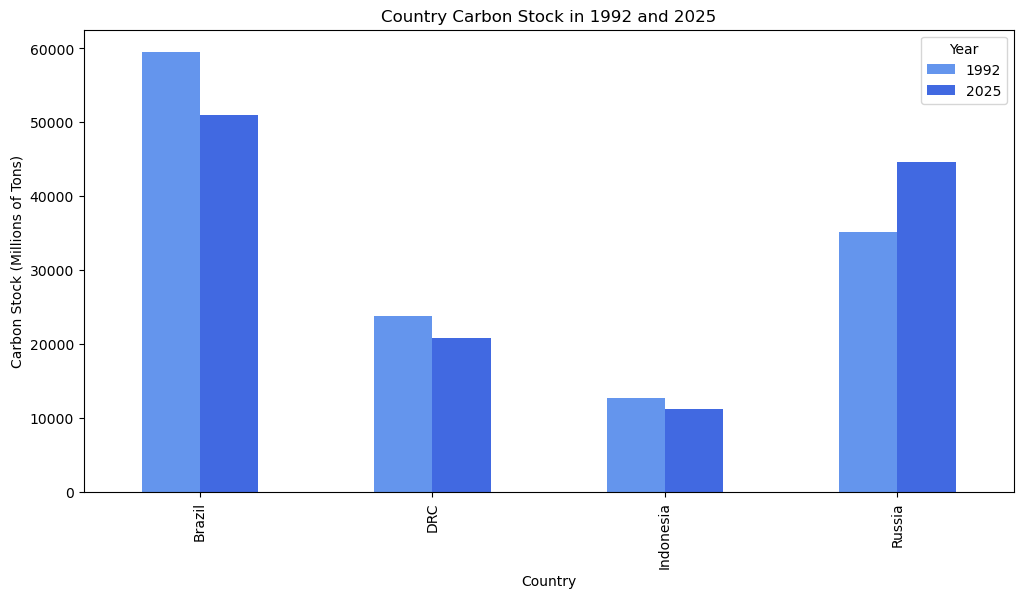

In [29]:
# plot bar chart with 1992 and 2025 side by side

# pivot data for bar chart
filt_comb_piv = filtered_comb.pivot(index='Country', columns='Year', values='Forest land')

# choose colors
colors = ['cornflowerblue', 'royalblue']

# create bar chart
filt_comb_piv.plot.bar(figsize=(12,6), color = colors)

# set title and y-axis label
plt.title('Country Carbon Stock in 1992 and 2025')
plt.ylabel('Carbon Stock (Millions of Tons)')

### 7.2) Percent Change in Carbon Stocks
Here I am plotting the percent change data calculated in section 7 to visualize how the carbon stock has changed year-over-year

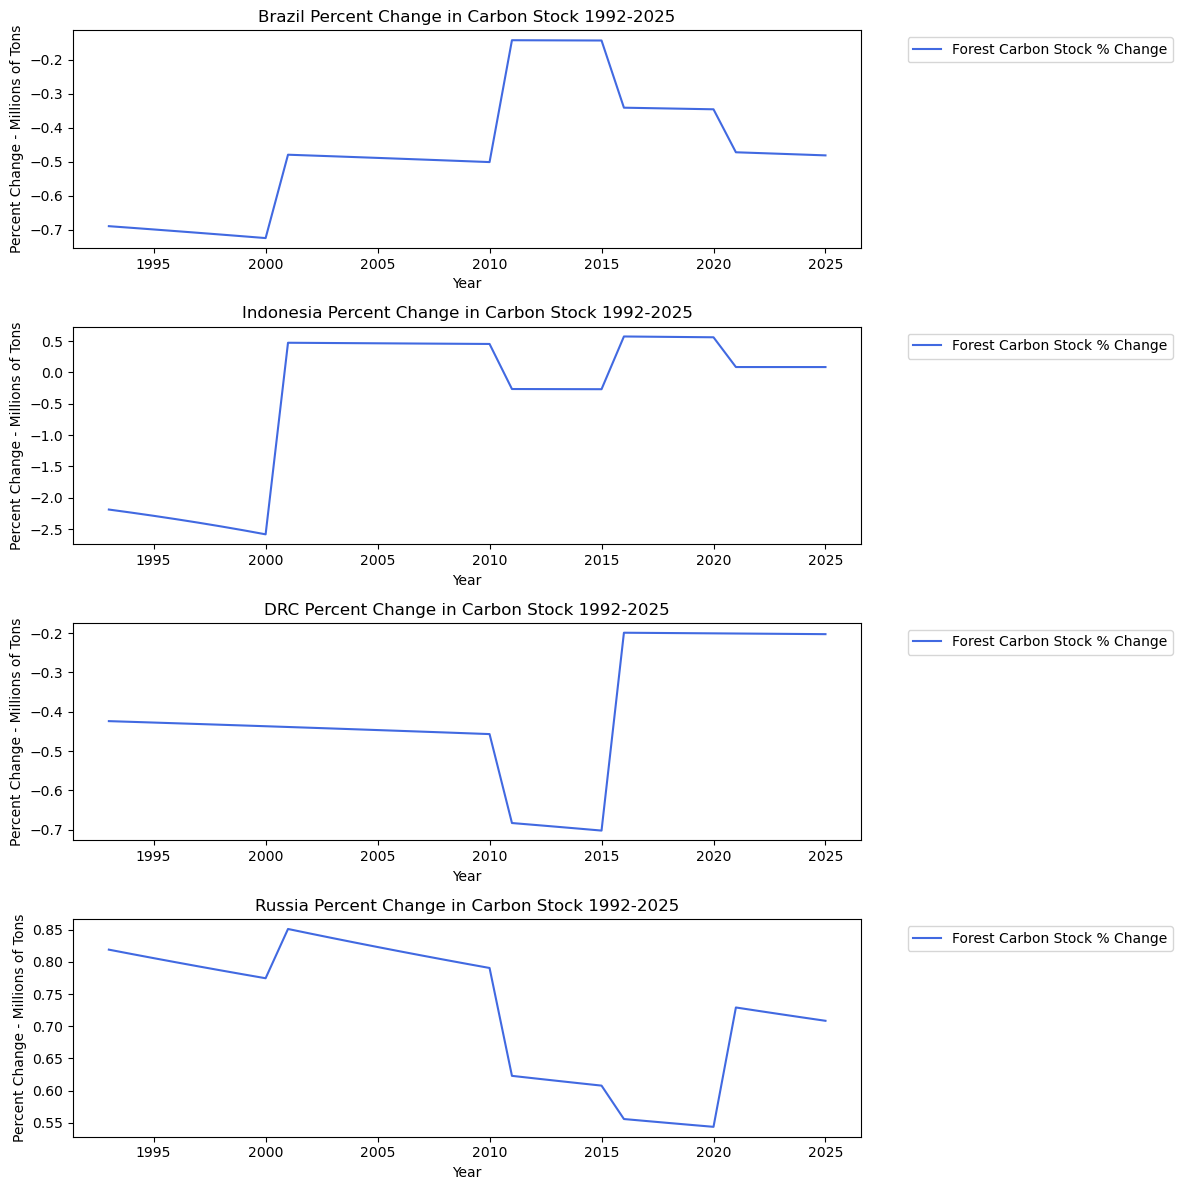

In [30]:
# Plot percent change y-o-y by country - carbon stock

# set up figure with 4 subplots
fig,axes = plt.subplots(figsize=(12,12), nrows=4)
ax0,ax1,ax2,ax3 = axes

# Brazil subplot
Carbon_stock_BR_pctchange.plot(kind='line', x= "Year", ax=ax0, color = 'royalblue')
# title, axes, legend
ax0.set_title('Brazil Percent Change in Carbon Stock 1992-2025')
ax0.set_ylabel('Percent Change - Millions of Tons')
ax0.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

Carbon_stock_ID_pctchange.plot(kind='line', x= "Year", ax=ax1, color = 'royalblue')
# title, axes, legend
ax1.set_title('Indonesia Percent Change in Carbon Stock 1992-2025')
ax1.set_ylabel('Percent Change - Millions of Tons')
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

Carbon_stock_DRC_pctchange.plot(kind='line', x= "Year", ax=ax2, color = 'royalblue')
# title, axes, legend
ax2.set_title('DRC Percent Change in Carbon Stock 1992-2025')
ax2.set_ylabel('Percent Change - Millions of Tons')
ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

Carbon_stock_RU_pctchange.plot(kind='line', x= "Year", ax=ax3, color = 'royalblue')
# title, axes, legend
ax3.set_title('Russia Percent Change in Carbon Stock 1992-2025')
ax3.set_ylabel('Percent Change - Millions of Tons')
ax3.legend(bbox_to_anchor=(1.05, 1), loc='upper left')


# fixing issue with overlapping axis titles
plt.tight_layout()

### 8) Naturally Regenerating versus Planted Forest

Here I am separating out the forest share data, pivoting for plotting, and filtering to 1992-2025. I am plotting the forest share data as a stacked area graph for each country and I am also plotting a 5th panel showing the percentage of forest that is planted by country as a line graph over time, allowing ease of comparison between countries

In [31]:
# process forest share data - separate into new dfs, pivot, filter years

# Brazil
# separate out forest share data
Share_forest_BR = df_BR[df_BR.Element == 'Share in Forest land']
# pivot data for ease of plotting
Share_forest_BR = Share_forest_BR.pivot_table(index='Year', columns='Item', values='Value', aggfunc='sum').reset_index()

# select timeframe to align with Russia data availability
Share_forest_BR = Share_forest_BR[(Share_forest_BR['Year'] >= 1992)  & (Share_forest_BR['Year'] <= 2025)]
print(Share_forest_BR)


# Indonesia
# separate out forest share
Share_forest_ID = df_ID[df_ID.Element == 'Share in Forest land']
# pivot data for ease of plotting
Share_forest_ID = Share_forest_ID.pivot_table(index='Year', columns='Item', values='Value', aggfunc='sum').reset_index()

# select timeframe to align with Russia data availability
Share_forest_ID = Share_forest_ID[(Share_forest_ID['Year'] >= 1992)  & (Share_forest_ID['Year'] <= 2025)]
print(Share_forest_ID)


# DRC
# separate out forest share
Share_forest_DRC = df_DRC[df_DRC.Element == 'Share in Forest land']
# pivot data for ease of plotting
Share_forest_DRC = Share_forest_DRC.pivot_table(index='Year', columns='Item', values='Value', aggfunc='sum').reset_index()

# select timeframe to align with Russia data availability
Share_forest_DRC = Share_forest_DRC[(Share_forest_BR['Year'] >= 1992)  & (Share_forest_DRC['Year'] <= 2025)]
print(Share_forest_DRC)


# Russia
# separate out forest share 
Share_forest_RU = df_RU[df_RU.Element == 'Share in Forest land']
# pivot data for ease of plotting
Share_forest_RU = Share_forest_RU.pivot_table(index='Year', columns='Item', values='Value', aggfunc='sum').reset_index()

# select timeframe to align with Russia data availability
Share_forest_RU = Share_forest_RU[(Share_forest_RU['Year'] >= 1992)  & (Share_forest_RU['Year'] <= 2025)]
print(Share_forest_RU)

Item  Year  Naturally regenerating forest  Planted Forest
2     1992                          99.41            0.59
3     1993                          99.40            0.60
4     1994                          99.40            0.60
5     1995                          99.39            0.61
6     1996                          99.38            0.62
7     1997                          99.37            0.63
8     1998                          99.37            0.63
9     1999                          99.36            0.64
10    2000                          99.35            0.65
11    2001                          99.28            0.72
12    2002                          99.21            0.79
13    2003                          99.14            0.86
14    2004                          99.06            0.94
15    2005                          98.99            1.01
16    2006                          98.91            1.09
17    2007                          98.84            1.16
18    2008    

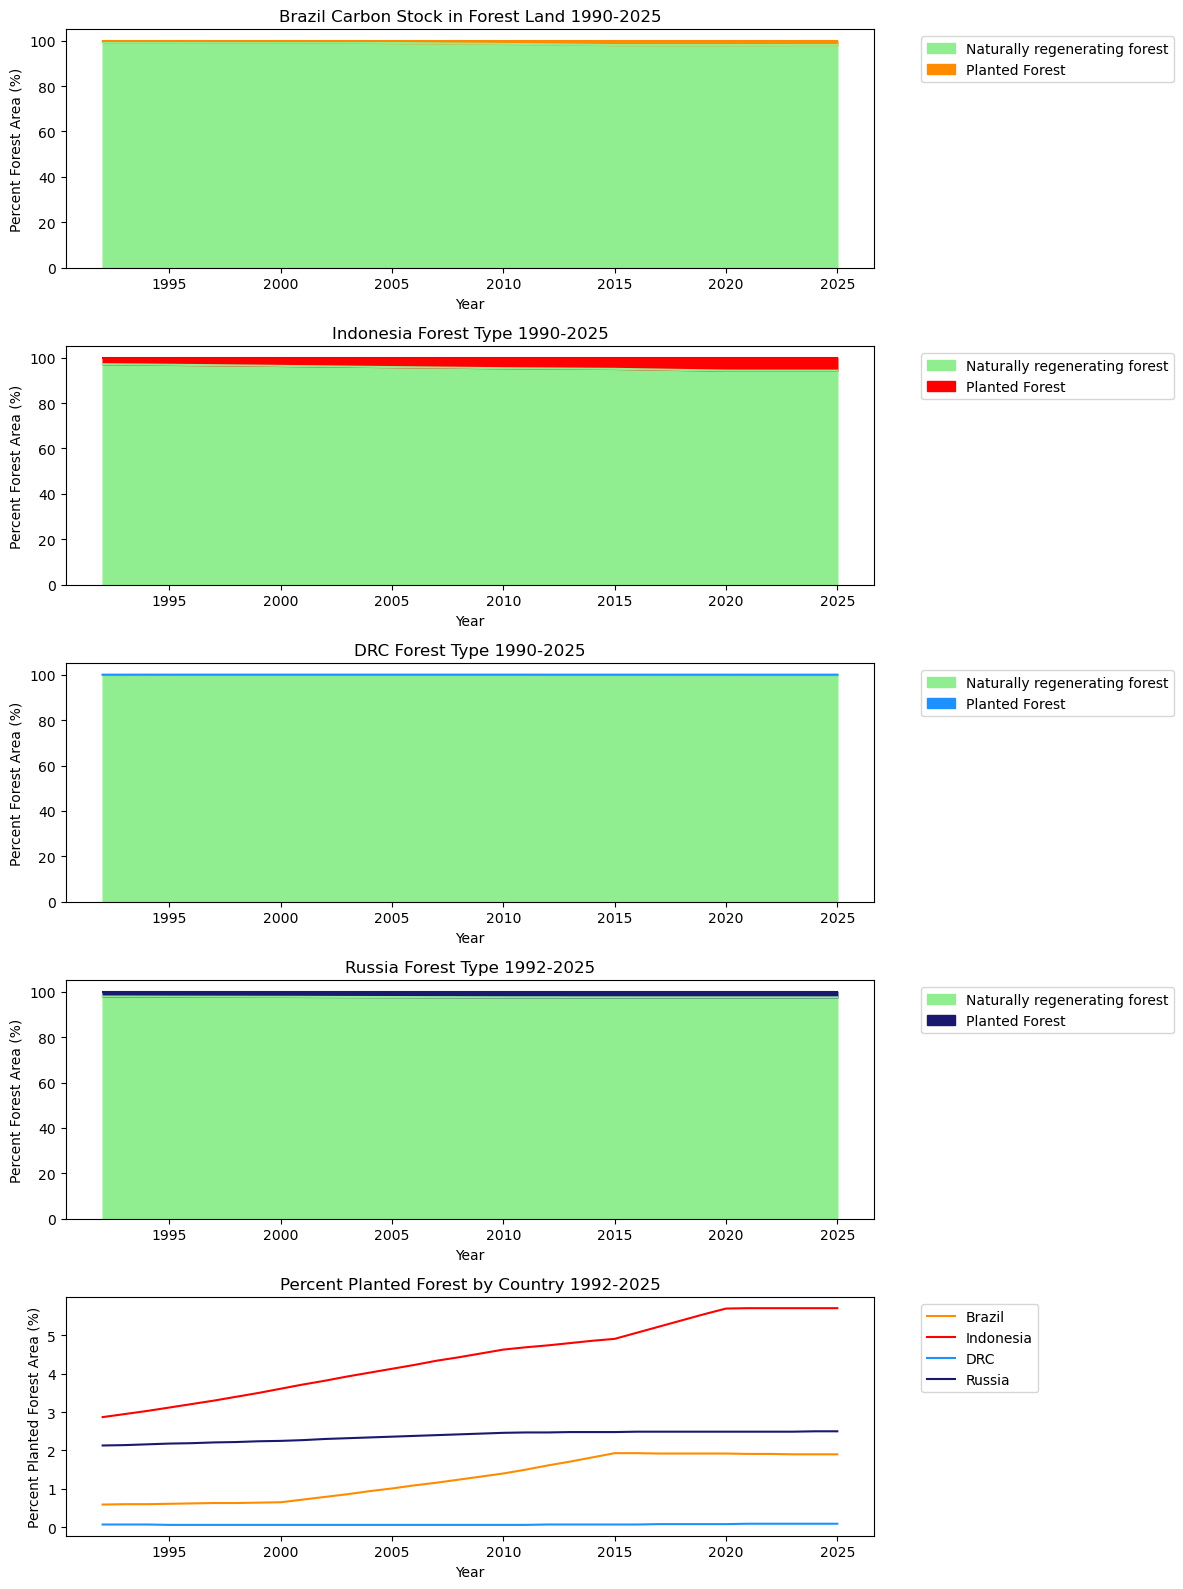

In [32]:
# plot forest share

# note: colors are chosen by country for consistency

# set up figure with 5 subplots
fig,axes = plt.subplots(figsize=(12,16), nrows=5)
ax0,ax1,ax2,ax3, ax4 = axes

#Brazil
# set colors
br_colors = ['lightgreen', 'darkorange']
# create plot
Share_forest_BR.plot(kind='area', x= "Year", stacked=True, ax=ax0, color = br_colors)
# title, axes, legend
ax0.set_title('Brazil Carbon Stock in Forest Land 1990-2025')
ax0.set_ylabel('Percent Forest Area (%)')
ax0.legend(bbox_to_anchor=(1.05, 1), loc='upper left')


# Indonesia
# set colors
id_colors = ['lightgreen', 'red']
# create plot
Share_forest_ID.plot(kind='area', x= "Year", stacked=True, ax=ax1, color=id_colors)
# title, axes, legend
ax1.set_title('Indonesia Forest Type 1990-2025')
ax1.set_ylabel('Percent Forest Area (%)')
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')


# DRC
# set colors
drc_colors = ['lightgreen', 'dodgerblue']
# create plot
Share_forest_DRC.plot(kind='area', x= "Year", stacked=True, ax=ax2, color = drc_colors)
# title, axes, legend
ax2.set_title('DRC Forest Type 1990-2025')
ax2.set_ylabel('Percent Forest Area (%)')
ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')


# Russia
# set colors
ru_colors = ['lightgreen', 'midnightblue']
# create plot
Share_forest_RU.plot(kind='area', x= "Year", stacked=True, ax=ax3, color = ru_colors)
# title, axes, legend
ax3.set_title('Russia Forest Type 1992-2025')
ax3.set_ylabel('Percent Forest Area (%)')
ax3.legend(bbox_to_anchor=(1.05, 1), loc='upper left')


# plot line graph showing % of planted forest
# Brazil line
Share_forest_BR.plot(x="Year", y = "Planted Forest", label = 'Brazil', ax=ax4, color = 'darkorange')
# Indonesia line
Share_forest_ID.plot(x="Year", y = "Planted Forest", label = 'Indonesia', ax=ax4, color = 'red')
# DRC line
Share_forest_DRC.plot(x="Year", y = "Planted Forest", label = 'DRC', ax=ax4, color = 'dodgerblue')
# Russia line
Share_forest_RU.plot(x="Year", y = "Planted Forest", label = 'Russia', ax=ax4, color = 'midnightblue')
# title, axes, legend
ax4.set_title('Percent Planted Forest by Country 1992-2025')
ax4.set_ylabel('Percent Planted Forest Area (%)')
ax4.legend(bbox_to_anchor=(1.05, 1), loc='upper left')


# ensure axes titles aren't overlapping
plt.tight_layout()



### Conclusions

#### Land Use by Area (thousands of hectares)

Forest lands are shrinking across 3 of the 4 countries examined. Russia is the outlier in this trend, with a seemingly very flat forest area and seemingly very little change across any of the three land types. 

To the contrary, in Brazil, forest land is shrinking, with other land types taking up more area. It’s important to note that other land in this dataset other land encompasses deserts, glaciers, barren lands, and built areas, amongst other land uses. Therefore, an increase in other lands could represent land used for development or desertification. 

In Indonesia, forest land is shrinking, with agricultural land expanding. It’s worth noting there is a jump in total land in 2000. This is an interesting finding and may denote another type of land transition not captured in these variables, or it may be highlighting a change in data gathering methodology.

In the DRC, forest land is also shrinking. Agricultural land and other lands are both increasing, with a jump in agricultural land around 2010. 


#### Percent Change in Land Use Type

Brazil saw a big increase in other land at the beginning of the measured period, to the extent that it crowds out the ability to visualize any other meaningful trend. When the Brazil data is filtered to only 2000-2025, the trends here are much clearer. Overall, the year-over-year change in agricultural land is positive but very small. Other land has a much bigger change from year-to-year, but also represents a smaller portion of Brazil’s overall land area. Forest lands continue to decline year-over-year, but the change is relatively small compared to the overall forest land, landing at around -0.5% to -1%. There has also been an improvement in the percent change in forest land since 2010.

In Indonesia, the large big unexplained jump in land area in 2000 aligns with a large percentage change in other land in 2000. There is a lot of variability year-over-year in Indonesia, with percent change in agricultural land and other lands oscillating between larger changes and smaller changes. After 2000, other land begins declining, see a negative percent change in many years following 2000. Percent change in agricultural land remains positive, aligning with background knowledge about oil palm agriculture in the region. Forest land percent change hovers around 0, ranging from slight positive to slight negative changes. 

In the DRC, forest is consistently slightly declining from a percent change standpoint. At the beginning of the studied period, there is a hpercentagecent change in other lanwhichthat later trades off with agricultural lands in 2009. After that point, agricultural lands continue to increase, though the rate at which they do varies substantially year-over-year. Other lands cycle between an increase in land area and a decline in land area. 

Russia again follows a different pattern, with forest land continually slightly increasing. Agricultural land is declining in the first part of the studied period, then jumps to a strong increase in 1997, later trending towards 0. Other land follows the opposite trend, increasing in the early period, dropping in 1997, before beginning to trend towards 0, with the exception of a decline in 2023. All 3 land types remain fairly stable after 2001. This may not be surprising given Russia is a country with a lot of land area and these results are being viewed on a percentage basis. 

#### Agricultural Land Share by Production Type

In Brazil, arable land (croplands) increased its share of agricultural land over time, with a small increase in permanent agriculture as well. Soy is an annual crop that would be grown on arable land, and may be contributing to this trend. There is also a decline in the percentage of agricultural land occupied by meadows and pasture. This does not necessarily indicate that pastureland is decreasing, given that agricultural land is slightly increasing in Brazil over the studied period.

Indonesia experienced the most dramatic changes in agricultural land share. Over the studied period, there was a large increase in the percentage of agricultural land occupied by permanent crops, with declines in both pastures and arable land. It’s worth noting that agricultural land is increasing in Indonesia over this period. Oil palm is a permanent agricultural crop and may be driving this trend, although additional data would be needed to confirm this. 

The DRC saw a big change in arable land as a percentage of agricultural land, with a small increase in permanent crops as well. Pastures declined as a percentage of agricultural land over this period. As found above, agricultural land overall in the DRC is increasing over this period. It is possible that cropland expansion is driving this agricultural land increase, though further analysis would be necessary to investigate further. 

Russia experienced a small decline in arable land, an increase in permanent crops, and an increase in meadows and pastures as percentages of agricultural land. On the whole, these categories were much more stable in Russia over this period than the other three countries

#### Carbon Stocks

a. 1992 vs 2025
Comparing 1992 versus 2025, carbon stocks declined in each country with the exception of Russia. Brazil experienced the largest decline in carbon stock in millions of tons. Russia’s carbon stock increased substantially over this period, despite relatively small percent changes in forest area over the period studied.

b. Percent change in Carbon Stocks

On a year-to-year basis, carbon stocks were typically shifting less than 1% relative to the previous year, with the exception of 1992-2000 in Indonesia.

In Brazil, forest stocks consistently declined year over year. However, the percent change decreased after 2000 and again after 2005. After 2015, we once again saw an increase in the decline of forest stocks on a year-over-year percent change basis. 

Indonesia’s pattern of carbon stocks is very interesting, with a high negative percent change reaching a maximum of -2.5% in the 1990’s. The rate of change has slowed substantially, with forest stocks fluctuating between a 0.5% positive percent change and a -0.5% negative percent change over the 2001 to 2025 period.

Similar to Brazil, the DRC has also consistently lost forest carbon stocks since 1992. However, similar to Indonesia, it has also successfully slowed the decline. The highest percent change period occurred from 2010-2015 at ~-0.7%, afterward reducing to ~-0.2%. 

Russia’s carbon stocks have increased in each year of the studied period, although the degree to which they have increased has varied over time. Carbon stocks grew the most from 1992 to 2005, then dropped from 2010 to 2020, before picking back up again in 2021. Russia seems to be on a relatively positive trajectory, and it will be interesting to monitor how its forest carbon stocks shift over the next few years

#### Naturally Regenerating versus Planted Forest

Planted forests increased the most as a percentage of forest land in Brazil and Indonesia. This is perhaps not surprising given the amount of attention that deforestation in these two countries has garnered, driving tree planting efforts. Planted forests make up a larger portion of forest land in Indonesia than in Brazil.

On the other hand, planted forests as a percentage have remained relatively stable in both the DRC and Russia, with very slight increases, representing a larger percentage of forest land in Russia than in the DRC.

This is relevant because planted forests are often less successful at supporting biodiversity and sequestering carbon than naturally regenerating forests.


#### Hypothesis Evaluation
1) Forests are the land use category experiencing the most change, driven by the transition of forest land into agricultural land and built land (categorized into other).
   
This hypothesis was incorrect, at least on a percentage change basis. All nations saw more change in agricultural land and other lands than in forest lands on a percent change basis. Given the inverse relationship observe between agricultural lands and other lands on many of the plots developed, there may be more transition occurring between these categories than initially anticipated. 

2) Forest carbon stocks are declining in all four nations.
   
This hypothesis was also incorrect, though only in the case of Russia. All other nations are experiencing forest carbon stock declines, though Indonesia has been increasing its forest carbon stock in recent years. 

3) The percentage of forest that is planted versus naturally regenerating is increasing over time.
   
This is technically true for all four nations, although the change in Russia and the DRC over the studied period is much smaller than the change in Brazil and Indonesia.
